In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'  
rcParams['axes.unicode_minus'] = False 

# 0단계: 데이터 불러오기, 기본 구조 확인

In [62]:
df = pd.read_csv('./data/walmart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [63]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


# 1단계: 제품별, 고객별 총매출 집계
- 단위 : Product_ID, User_ID
- 목적: 각 제품/고객이 전체 매출에 얼마나 기여하고 있는지 계산

In [64]:
product_sales = df.groupby('Product_ID',as_index=False)['Purchase'].sum()
product_sales

,Product_ID,Purchase
0,P00000142,12837476
1,P00000242,3967496
2,P00000342,1296475
3,P00000442,441173
4,P00000542,807212
...,...,...
3626,P0099442,2870383
3627,P0099642,83710
3628,P0099742,991948
3629,P0099842,737312


In [65]:
customer_sales = df.groupby('User_ID',as_index=False)['Purchase'].sum()
customer_sales

,User_ID,Purchase
0,1000001,334093
1,1000002,810472
2,1000003,341635
3,1000004,206468
4,1000005,821001
...,...,...
5886,1006036,4116058
5887,1006037,1119538
5888,1006038,90034
5889,1006039,590319


#  2단계: 정렬 및 누적 매출 계산
- 목적: 상위 제품/고객이 전체 매출에 얼마나 기여하는지 확인

In [ ]:
# 내림차순 정렬

product_sales = product_sales.sort_values(
    by='Purchase',
    ascending=False
).reset_index(drop=True)
customer_sales = customer_sales.sort_values(by='Purchase',
    ascending=False
).reset_index(drop=True)
#product_sales, customer_sales

In [67]:
# 제품별

# 전체 매출 
total_sales = product_sales['Purchase'].sum()
# 누적 매출 계산
product_sales['cum_Purchase'] = product_sales['Purchase'].cumsum()
# 누적 매출 비율 계산
product_sales['cum_Purchase_ratio'] = (
    product_sales['cum_Purchase'] / total_sales_p
)

product_sales.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio
0,P00025442,27995166,27995166,0.005494
1,P00110742,26722309,54717475,0.010738
2,P00255842,25168963,79886438,0.015677
3,P00059442,24338343,104224781,0.020453
4,P00184942,24334887,128559668,0.025228


In [ ]:
# 고객별

# 누적 매출 계산
customer_sales['cum_Purchase'] = customer_sales['Purchase'].cumsum()
# 누적 매출 비율 계산
customer_sales['cum_Purchase_ratio'] = (
    customer_sales['cum_Purchase'] / total_sales
)

customer_sales.head()

,User_ID,Purchase,cum_Purchase,cum_Purchase_ratio
0,1004277,10536909,10536909,0.002068
1,1001680,8699596,19236505,0.003775
2,1002909,7577756,26814261,0.005262
3,1001941,6817493,33631754,0.006600
4,1000424,6573609,40205363,0.007890


# 3단계. 제품/고객별 누적매출 비율 계산
- 목적: 상위 몇 %의 제품/고객이 몇 %를 차지하는가

In [69]:
# 전체 제품 수
total_products = len(product_sales)
# 누적 제품 비율 계산
product_sales['cum_Product_ratio'] = (
    (product_sales.index + 1) / total_products
)

product_sales.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_Product_ratio
0,P00025442,27995166,27995166,0.005494,0.000275
1,P00110742,26722309,54717475,0.010738,0.000551
2,P00255842,25168963,79886438,0.015677,0.000826
3,P00059442,24338343,104224781,0.020453,0.001102
4,P00184942,24334887,128559668,0.025228,0.001377


In [70]:
# 전체 고객 수
total_customers = len(customer_sales)
# 누적 고객 비율 계산
customer_sales['cum_User_ratio'] = (
    (customer_sales.index + 1) / total_customers
)

customer_sales.head()

,User_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_User_ratio
0,1004277,10536909,10536909,0.002068,0.000170
1,1001680,8699596,19236505,0.003775,0.000340
2,1002909,7577756,26814261,0.005262,0.000509
3,1001941,6817493,33631754,0.006600,0.000679
4,1000424,6573609,40205363,0.007890,0.000849


# 4단계: 파레토 구조 검증(상위 20%)
- 목적: 상위 20% 제품/고객이 전체 매출의 몇 %를 차지하는가

In [83]:
# 상위 20% 필터링
top20_products = product_sales[
    product_sales['cum_Product_ratio'] <= 0.20
]
# 해당 시점의 누적 매출 비율 확인
top20_Purchase_P_ratio = (
    top20_products['cum_Purchase_ratio'].max()
)

top20_Purchase_P_ratio

0.7325141840936195

In [82]:
# 상위 20% 필터링
top20_customers = customer_sales[
    customer_sales['cum_User_ratio'] <= 0.20
]
# 해당 시점의 누적 매출 비율 확인
top20_Purchase_C_ratio = (
    top20_customers['cum_Purchase_ratio'].max()
)

top20_Purchase_C_ratio

0.5533258871073328

# 결론: 파레토 법칙의 강도로 보아 고객보다 제품 집중도가 더 높음 

상위 20% 제품이 전체 매출의 약 **73%**를 차지하는 것으로 보아 소수의 인기 제품이 매출을 견인함.
반면, 상위 20% 고객은 전체 매출의 약 **55%**를 차지.

∴ "어떤 제품을 파느냐"가 "누구에게 파느냐"보다 더 중요하며 제품 포트폴리오 관리가 즉각적인 효과를 볼 가능성이 크다

In [ ]:
# 6단계: 고부가가치 제품 리스트 추출

In [80]:
high_value_products = top20_products.copy()
high_value_products.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_Product_ratio
0,P00025442,27995166,27995166,0.005494,0.000275
1,P00110742,26722309,54717475,0.010738,0.000551
2,P00255842,25168963,79886438,0.015677,0.000826
3,P00059442,24338343,104224781,0.020453,0.001102
4,P00184942,24334887,128559668,0.025228,0.001377


# 7단계: 결과요약 확인

In [85]:
summary = {
    "전체 제품 수": total_products,
    "고부가가치 제품 수": len(high_value_products),
    "고부가가치 제품 비율": len(high_value_products) / total_products,
    "고부가가치 제품 매출 비중": top20_Purchase_P_ratio
}
pd.Series(summary)

전체 제품 수           3631.000000
고부가가치 제품 수         726.000000
고부가가치 제품 비율          0.199945
고부가가치 제품 매출 비중       0.732514
dtype: float64

# 8단계: 파레토 커브 시각화
- 목적: 시각적으로 '소수의 제품이 매출을 견인'하는 구조를 보여주기 위함

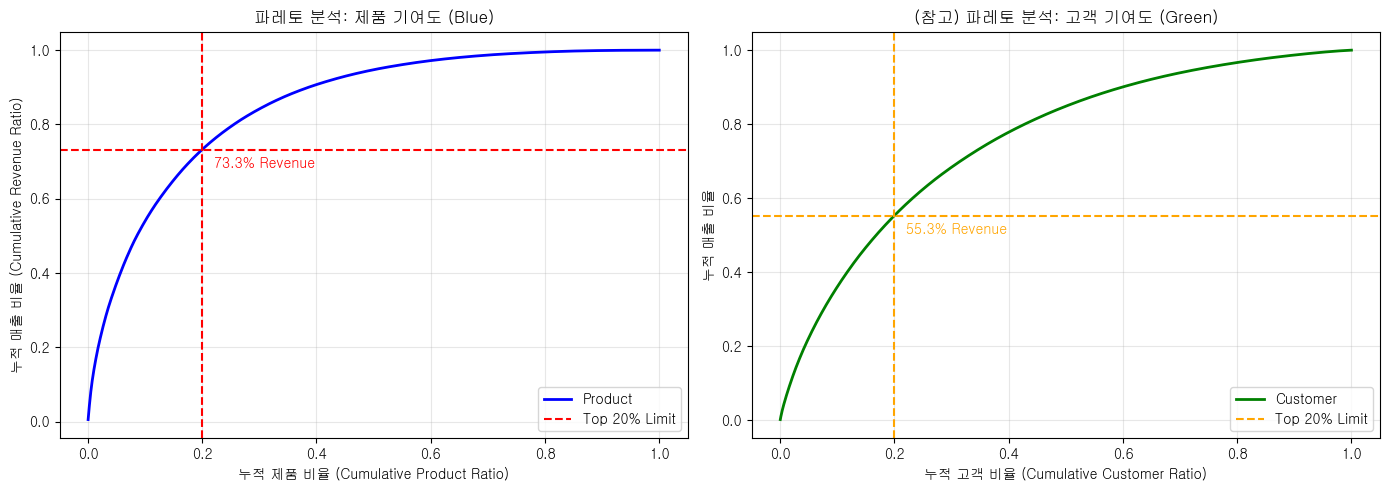

In [96]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 첫 번째 그래프: 제품 (파란색 테마) ---
plt.subplot(1, 2, 1)
plt.plot(
    product_sales['cum_Product_ratio'],
    product_sales['cum_Purchase_ratio'],
    color='blue',       # [변경] 선 색상: 파랑
    linewidth=2,        # 선 두께
    label='Product'
)

# 상위 20% 기준선 (빨간색 점선)
plt.axvline(x=0.20, color='red', linestyle='--', label='Top 20% Limit')
plt.axhline(y=top20_Purchase_P_ratio, color='red', linestyle='--')

# 수치 텍스트 표시 (그래프 위에 % 숫자가 보이도록 추가)
plt.text(0.22, top20_Purchase_P_ratio - 0.05, 
         f'{top20_Purchase_P_ratio*100:.1f}% Revenue', color='red', fontweight='bold')

plt.xlabel('누적 제품 비율 (Cumulative Product Ratio)')
plt.ylabel('누적 매출 비율 (Cumulative Revenue Ratio)')
plt.title('파레토 분석: 제품 기여도 (Blue)')
plt.grid(True, alpha=0.3) # 격자 추가
plt.legend()


# --- 두 번째 그래프: 고객 (초록색 테마) ---
plt.subplot(1, 2, 2)
plt.plot(
    customer_sales['cum_User_ratio'],
    customer_sales['cum_Purchase_ratio'],
    color='green',      # [변경] 선 색상: 초록
    linewidth=2,        # 선 두께
    label='Customer'
)

# 상위 20% 기준선 (주황색 점선 - 구분되게 설정)
plt.axvline(x=0.20, color='orange', linestyle='--', label='Top 20% Limit')
plt.axhline(y=top20_customer_ratio, color='orange', linestyle='--')

# 수치 텍스트 표시
plt.text(0.22, top20_customer_ratio - 0.05, 
         f'{top20_customer_ratio*100:.1f}% Revenue', color='orange', fontweight='bold')

plt.xlabel('누적 고객 비율 (Cumulative Customer Ratio)')
plt.ylabel('누적 매출 비율')
plt.title('(참고) 파레토 분석: 고객 기여도 (Green)')
plt.grid(True, alpha=0.3) # 격자 추가
plt.legend()

plt.tight_layout()
plt.show()